## Choosing the Huber threshold for 2D TV loss

Load a representative US slice, look at the distribution of neighboring-pixel
intensity differences, and pick a threshold so that most "speckle noise"
differences fall in the L2 (quadratic) region while real edges get pushed into
the L1 (linear) region of the Huber loss.

shape=(708, 944), dtype=float32, min=0.0, max=254.0, mean=25.73


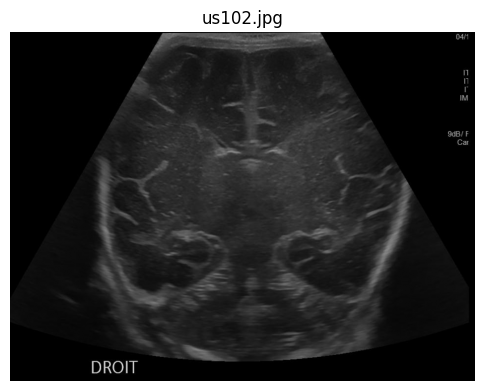

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image

IMAGE_PATH = Path(
    "/home/zchen/Code/NeUF/data/cerebral_data/Pre_traitement_echo_v2/"
    "Recalage/Patient0/us_recal_original/us102.jpg"
)

img = np.asarray(Image.open(IMAGE_PATH).convert("L"), dtype=np.float32)
print(f"shape={img.shape}, dtype={img.dtype}, min={img.min()}, max={img.max()}, mean={img.mean():.2f}")

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.imshow(img, cmap="gray")
ax.set_title(IMAGE_PATH.name)
ax.axis("off")
plt.show()

In [9]:
# Neighboring-pixel differences (signed) along rows and columns.
diff_h = img[1:, :] - img[:-1, :]   # vertical neighbors (row direction)
diff_w = img[:, 1:] - img[:, :-1]   # horizontal neighbors (col direction)

abs_diff = np.concatenate([np.abs(diff_h).ravel(), np.abs(diff_w).ravel()])

percentiles = [50, 75, 90, 95, 96, 97, 98, 99]
pct_values = np.percentile(abs_diff, percentiles)
for p, v in zip(percentiles, pct_values):
    print(f"p{p:>5}: |Δ| = {v:6.2f}")
print(f"mean |Δ|  : {abs_diff.mean():.2f}")
print(f"std  |Δ|  : {abs_diff.std():.2f}")

p   50: |Δ| =   0.00
p   75: |Δ| =   2.00
p   90: |Δ| =   3.00
p   95: |Δ| =   5.00
p   96: |Δ| =   6.00
p   97: |Δ| =   7.00
p   98: |Δ| =   8.00
p   99: |Δ| =  12.00
mean |Δ|  : 1.43
std  |Δ|  : 5.29


In [10]:
pct_values[-5:]

array([ 5.,  6.,  7.,  8., 12.])

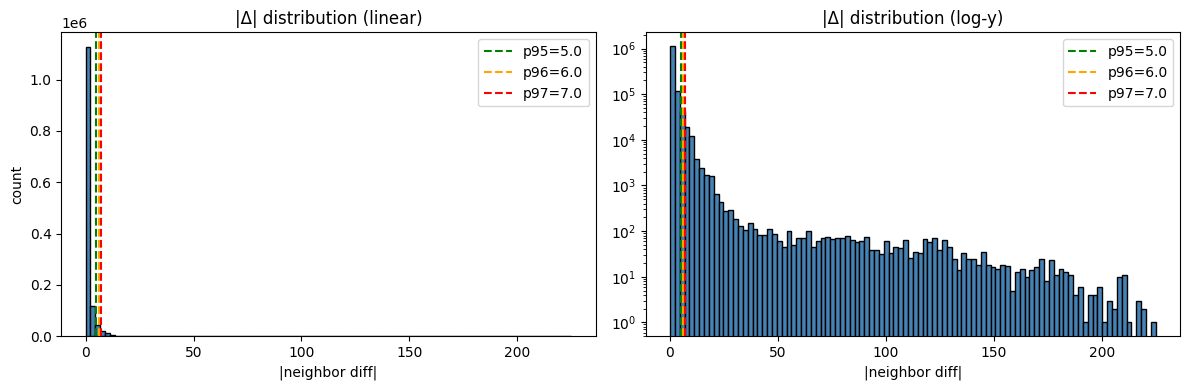

In [12]:
# Distribution visualisation. Linear histogram on the left emphasises the speckle
# bulk; log-y on the right exposes the edge tail where L1 behaviour matters.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(abs_diff, bins=100, range=(0, abs_diff.max()), color="steelblue", edgecolor="black")
axes[0].set_title("|Δ| distribution (linear)")
axes[0].set_xlabel("|neighbor diff|")
axes[0].set_ylabel("count")

axes[1].hist(abs_diff, bins=100, range=(0, abs_diff.max()), color="steelblue", edgecolor="black")
axes[1].set_yscale("log")
axes[1].set_title("|Δ| distribution (log-y)")
axes[1].set_xlabel("|neighbor diff|")

for ax in axes:
    for p, v, c in zip([95, 96, 97, 98, 99], pct_values[-5:], ["green", "orange", "red"]):
        ax.axvline(v, color=c, linestyle="--", label=f"p{p}={v:.1f}")
    ax.legend()

plt.tight_layout()
plt.show()

### Choosing the threshold

Rule of thumb for Huber TV on speckled US:
- Speckle-dominated differences usually live in the bulk (≤ ~p90–p95).
- Real tissue edges live in the tail (≥ ~p99).
- Pick the threshold near the **"knee"** of the log-y histogram — where the
  curve transitions from the speckle hump to the heavy edge tail.
- Using `p95` is a safe default; `p90` gives stronger smoothing, `p99` preserves
  more edges.

In [4]:
# Pick a percentile and report the corresponding threshold value for your Huber TV.
CHOSEN_PCT = 95
threshold = float(np.percentile(abs_diff, CHOSEN_PCT))
print(f"Chosen threshold (p{CHOSEN_PCT}) = {threshold:.3f}")
print(f"Fraction of |Δ| below threshold (staying in L2 region): "
      f"{(abs_diff < threshold).mean() * 100:.2f}%")

Chosen threshold (p95) = 5.000
Fraction of |Δ| below threshold (staying in L2 region): 93.33%


In [5]:
# Sanity check: apply the proposed Huber TV on this single image with the chosen
# threshold, and compare against plain L1/L2 to make sure the value is sensible.
d = torch.from_numpy(img)

def huber_tv(d: torch.Tensor, delta: float) -> torch.Tensor:
    diff_h = d[1:, :] - d[:-1, :]
    diff_w = d[:, 1:] - d[:, :-1]
    tv_h = torch.nn.functional.huber_loss(diff_h, torch.zeros_like(diff_h), delta=delta, reduction="mean")
    tv_w = torch.nn.functional.huber_loss(diff_w, torch.zeros_like(diff_w), delta=delta, reduction="mean")
    return tv_h + tv_w

def l1_tv(d: torch.Tensor) -> torch.Tensor:
    return torch.mean(torch.abs(d[1:, :] - d[:-1, :])) + torch.mean(torch.abs(d[:, 1:] - d[:, :-1]))

def l2_tv(d: torch.Tensor) -> torch.Tensor:
    return torch.mean((d[1:, :] - d[:-1, :]) ** 2) + torch.mean((d[:, 1:] - d[:, :-1]) ** 2)

for pct in (75, 90, 95, 99):
    delta_pct = float(np.percentile(abs_diff, pct))
    print(f"huber_tv(delta=p{pct}={delta_pct:6.2f}) = {huber_tv(d, delta_pct).item():.4f}")
print(f"l1_tv                       = {l1_tv(d).item():.4f}")
print(f"l2_tv                       = {l2_tv(d).item():.4f}")

huber_tv(delta=p75=  2.00) = 4.0874
huber_tv(delta=p90=  3.00) = 5.3610
huber_tv(delta=p95=  5.00) = 7.2326
huber_tv(delta=p99= 12.00) = 11.2486
l1_tv                       = 2.8614
l2_tv                       = 60.0328


### Visualising the effect of each threshold

Simulate what the image would look like after a Huber-TV prior with each
candidate threshold. We use Perona-Malik style anisotropic diffusion: pixels
where the local gradient is **below** the threshold get smoothed (L2 region),
pixels **above** are left alone (L1 / edge-preserving region).

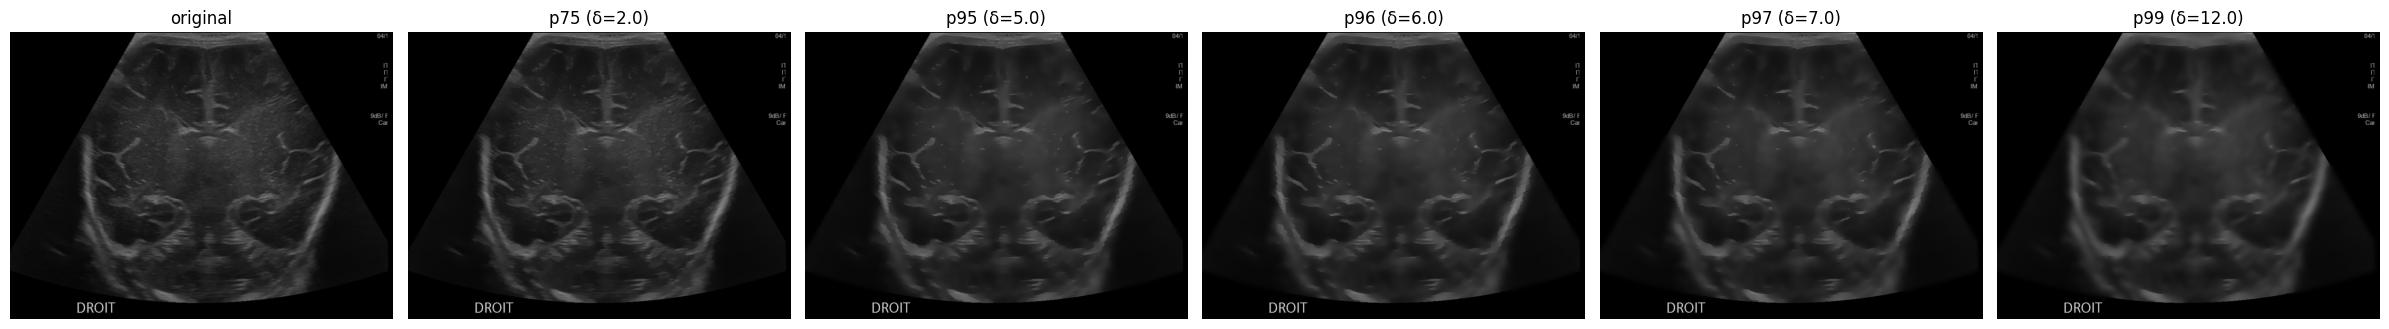

In [15]:
def anisotropic_smooth(image: np.ndarray, delta: float, n_iters: int = 80, step: float = 0.2) -> np.ndarray:
    """Perona-Malik with a hard edge-stopping function g(|∇I|) = 1[|∇I|<delta]."""
    x = image.astype(np.float32).copy()
    for _ in range(n_iters):
        dn = np.zeros_like(x); dn[1:, :]  = x[:-1, :] - x[1:, :]
        ds = np.zeros_like(x); ds[:-1, :] = x[1:, :]  - x[:-1, :]
        de = np.zeros_like(x); de[:, :-1] = x[:, 1:]  - x[:, :-1]
        dw = np.zeros_like(x); dw[:, 1:]  = x[:, :-1] - x[:, 1:]
        gn = (np.abs(dn) < delta).astype(np.float32)
        gs = (np.abs(ds) < delta).astype(np.float32)
        ge = (np.abs(de) < delta).astype(np.float32)
        gw = (np.abs(dw) < delta).astype(np.float32)
        x = x + step * (gn * dn + gs * ds + ge * de + gw * dw)
    return x


percentiles_to_show = [75, 95, 96, 97, 99]
smoothed = {p: anisotropic_smooth(img, float(np.percentile(abs_diff, p))) for p in percentiles_to_show}

fig, axes = plt.subplots(1, len(percentiles_to_show) + 1, figsize=(4 * (len(percentiles_to_show) + 1), 4))
axes[0].imshow(img, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("original")
axes[0].axis("off")
for ax, p in zip(axes[1:], percentiles_to_show):
    delta = float(np.percentile(abs_diff, p))
    ax.imshow(smoothed[p], cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"p{p} (δ={delta:.1f})")
    ax.axis("off")
plt.tight_layout()
plt.show()

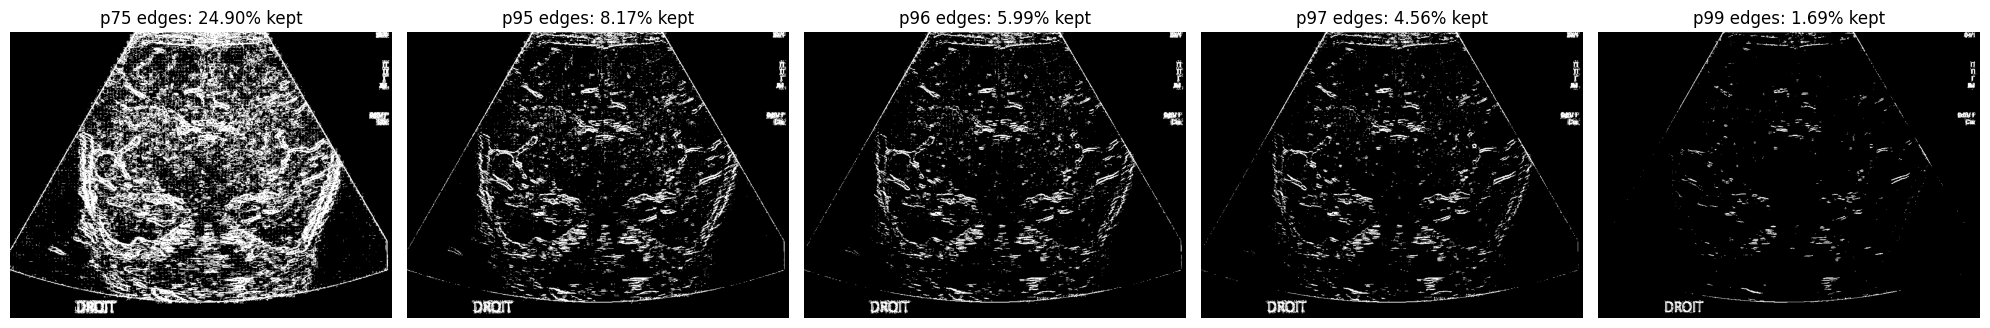

In [16]:
# Edge masks: which pixels are "kept as edges" (|Δ| > δ) for each threshold.
fig, axes = plt.subplots(1, len(percentiles_to_show), figsize=(4 * len(percentiles_to_show), 4))
for ax, p in zip(axes, percentiles_to_show):
    delta = float(np.percentile(abs_diff, p))
    mask_h = np.zeros_like(img, dtype=bool)
    mask_h[1:, :] = np.abs(diff_h) > delta
    mask_w = np.zeros_like(img, dtype=bool)
    mask_w[:, 1:] = np.abs(diff_w) > delta
    edge_mask = mask_h | mask_w
    ax.imshow(edge_mask, cmap="gray")
    ax.set_title(f"p{p} edges: {edge_mask.mean()*100:.2f}% kept")
    ax.axis("off")
plt.tight_layout()
plt.show()

### SVD principal components and reconstruction

Treat the grayscale image as a matrix. SVD decomposes it into ranked singular components; keeping only the first `k` components gives a rank-`k` reconstruction of the original image.

In [ ]:
# SVD decomposition of the grayscale image.
# This uses the image-compression form of SVD: img ~= U[:, :k] @ diag(S[:k]) @ Vt[:k, :].
img_svd = img.astype(np.float64)
U, singular_values, Vt = np.linalg.svd(img_svd, full_matrices=False)

energy_ratio = singular_values**2 / np.sum(singular_values**2)
cumulative_energy = np.cumsum(energy_ratio)

energy_targets = [0.80, 0.90, 0.95, 0.99]
energy_k = {
    target: int(np.searchsorted(cumulative_energy, target) + 1)
    for target in energy_targets
}

print(f"SVD shapes: U={U.shape}, S={singular_values.shape}, Vt={Vt.shape}")
for target, k in energy_k.items():
    print(f"{target:.0%} cumulative energy: k={k}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(singular_values, color="steelblue")
axes[0].set_title("Singular values")
axes[0].set_xlabel("component index")
axes[0].set_ylabel("singular value")
axes[0].set_yscale("log")

axes[1].plot(cumulative_energy, color="darkorange")
for target, k in energy_k.items():
    axes[1].axhline(target, color="gray", linewidth=0.8, linestyle="--")
    axes[1].axvline(k, color="gray", linewidth=0.8, linestyle=":")
    axes[1].text(k, target, f" k={k}", va="bottom", fontsize=9)
axes[1].set_title("Cumulative energy")
axes[1].set_xlabel("number of kept components")
axes[1].set_ylabel("energy ratio")
axes[1].set_ylim(0, 1.01)

plt.tight_layout()
plt.show()

In [ ]:
# Visualize the strongest singular components.
# Each component is S[i] * outer(U[:, i], Vt[i, :]).
n_components_to_view = 6
fig, axes = plt.subplots(1, n_components_to_view, figsize=(4 * n_components_to_view, 4))
for i, ax in enumerate(axes):
    component = singular_values[i] * np.outer(U[:, i], Vt[i, :])
    lo, hi = np.percentile(component, [1, 99])
    ax.imshow(component, cmap="gray", vmin=lo, vmax=hi)
    ax.set_title(f"PC {i + 1}\nenergy={energy_ratio[i] * 100:.2f}%")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# Reconstruct the image from the first k singular components.
def svd_reconstruct(k: int) -> np.ndarray:
    k = int(np.clip(k, 1, len(singular_values)))
    reconstruction = (U[:, :k] * singular_values[:k]) @ Vt[:k, :]
    return np.clip(reconstruction, 0, 255)


def image_mse(reference: np.ndarray, reconstruction: np.ndarray) -> float:
    return float(np.mean((reference - reconstruction) ** 2))


def image_psnr(reference: np.ndarray, reconstruction: np.ndarray, data_range: float = 255.0) -> float:
    mse = image_mse(reference, reconstruction)
    if mse == 0:
        return float("inf")
    return float(20 * np.log10(data_range / np.sqrt(mse)))

k_95 = energy_k[0.95]
k_99 = energy_k[0.99]
components_to_show = sorted({
    k for k in [1, 5, 10, 20, 50, 100, k_95, k_99]
    if 1 <= k <= len(singular_values)
})

reconstructions = {k: svd_reconstruct(k) for k in components_to_show}

fig, axes = plt.subplots(1, len(components_to_show) + 1, figsize=(4 * (len(components_to_show) + 1), 4))
axes[0].imshow(img_svd, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("original")
axes[0].axis("off")

for ax, k in zip(axes[1:], components_to_show):
    reconstruction = reconstructions[k]
    mse = image_mse(img_svd, reconstruction)
    psnr = image_psnr(img_svd, reconstruction)
    ax.imshow(reconstruction, cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"k={k}\nenergy={cumulative_energy[k - 1] * 100:.1f}%\nPSNR={psnr:.1f} dB")
    ax.axis("off")

plt.tight_layout()
plt.show()

# Pick this as a convenient restored image for later cells.
svd_restored = reconstructions[k_95]
print(f"svd_restored uses k={k_95} components, MSE={image_mse(img_svd, svd_restored):.3f}, PSNR={image_psnr(img_svd, svd_restored):.2f} dB")